<a href="https://colab.research.google.com/github/vathanababuji05-netizen/project_1/blob/main/project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("/content/ONINE_FOOD_DELIVERY_ANALYSIS.csv")



In [ ]:
print(df.head())

    Order_ID Customer_ID  Customer_Age Customer_Gender     City     Area  \
0  ORD000001    CUST6948          19.0            Male      NaN  Central   
1  ORD000002    CUST6515           NaN          Female  Chennai    North   
2  ORD000003    CUST1765           NaN            Male    Delhi      NaN   
3  ORD000004    CUST2744           NaN            Male   Mumbai  Central   
4  ORD000005    CUST4389          57.0          Female  Chennai    South   

  Restaurant_ID Restaurant_Name Cuisine_Type  Order_Date  ... Final_Amount  \
0        RES936   Restaurant_29      Chinese  10/20/2024  ...          NaN   
1        RES689  Restaurant_419      Chinese   8/12/2024  ...       4849.0   
2        RES723  Restaurant_244      Arabian   12/8/2024  ...        737.0   
3        RES951  Restaurant_178      Chinese   10/8/2024  ...          NaN   
4        RES419  Restaurant_262      Chinese    2/4/2024  ...        352.0   

   Payment_Mode  Order_Status  Cancellation_Reason  Delivery_Partner_ID  \

In [9]:
# Data Cleaning
# ----------------------

print(df.shape)
print(df.isnull().sum())

(100000, 25)
Order_ID                   0
Customer_ID                0
Customer_Age           50093
Customer_Gender        24856
City                   16726
Area                   16685
Restaurant_ID              0
Restaurant_Name            0
Cuisine_Type           16885
Order_Date              1014
Order_Time              1998
Delivery_Time_Min      33359
Distance_km            33470
Order_Value            33327
Discount_Applied       16715
Final_Amount           55697
Payment_Mode           19911
Order_Status               0
Cancellation_Reason    90969
Delivery_Partner_ID        0
Delivery_Rating        16523
Restaurant_Rating          0
Order_Day                  0
Peak_Hour              32962
Profit_Margin              0
dtype: int64


In [10]:

# Remove duplicates
df.drop_duplicates(inplace=True)

In [11]:
# Fill missing values
for col in df.select_dtypes(include='number'):
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_12340/223973801.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_12340/223973801.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [12]:
# KPI Analysis
# ----------------------

total_orders = len(df)
print("Total Orders:", total_orders)

Total Orders: 100000


In [13]:
# Revenue
total_revenue = df['Final_Amount'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 151268398.0


In [14]:
# Average Order Value
avg_order_value = df['Final_Amount'].mean()
print("Average Order Value:", avg_order_value)

Average Order Value: 1512.68398


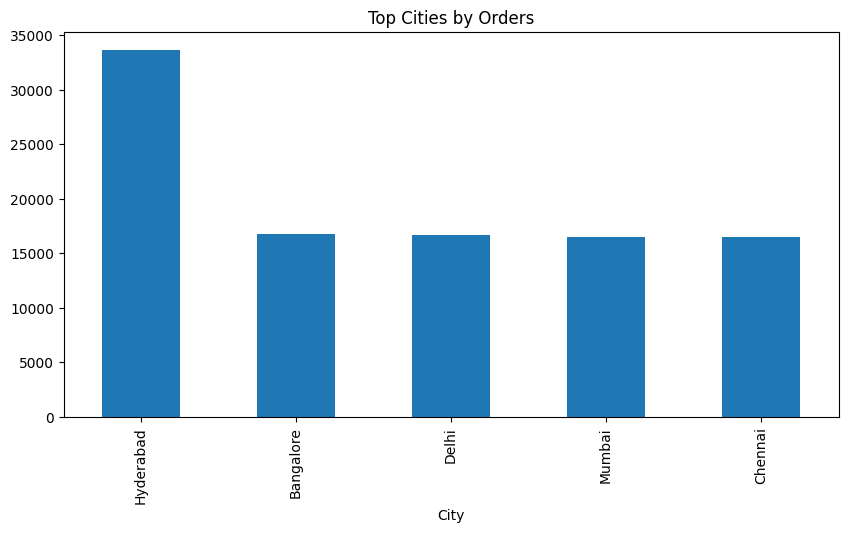

In [15]:
# City-wise Orders
# ----------------------

city_orders = df['City'].value_counts().head(10)

plt.figure(figsize=(10,5))
city_orders.plot(kind='bar')
plt.title("Top Cities by Orders")
plt.show()

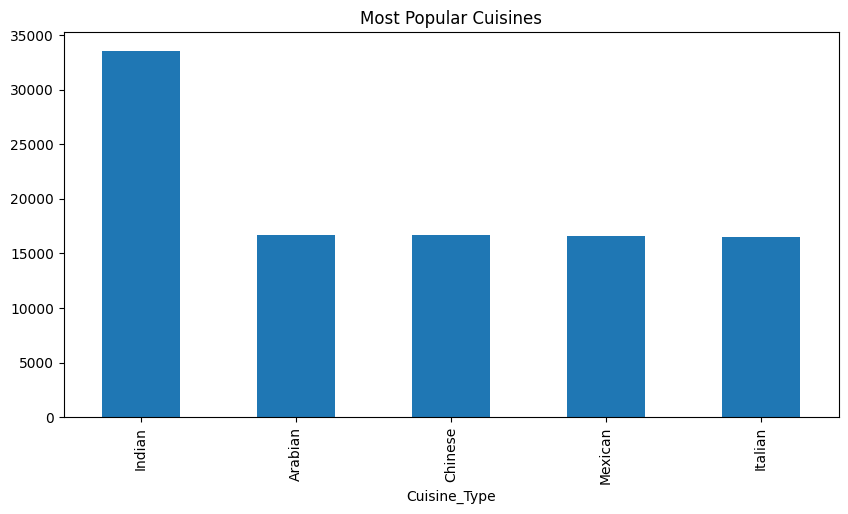

In [16]:
#Cuisine Analysis
# ----------------------

cuisine = df['Cuisine_Type'].value_counts().head(10)

plt.figure(figsize=(10,5))
cuisine.plot(kind='bar')
plt.title("Most Popular Cuisines")
plt.show()

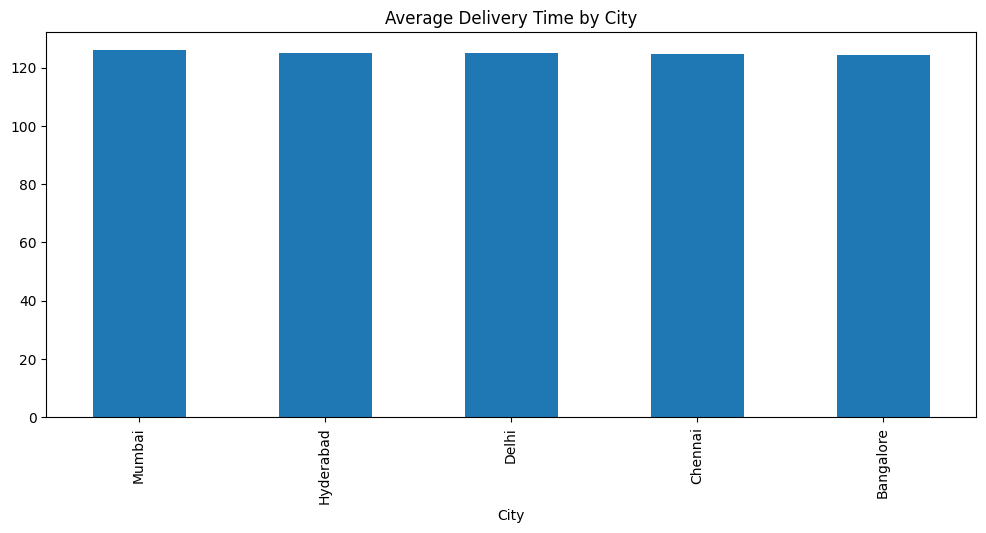

In [17]:
# Delivery Time Analysis
# ----------------------

avg_delivery = df.groupby('City')['Delivery_Time_Min'].mean()

plt.figure(figsize=(12,5))
avg_delivery.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Average Delivery Time by City")
plt.show()

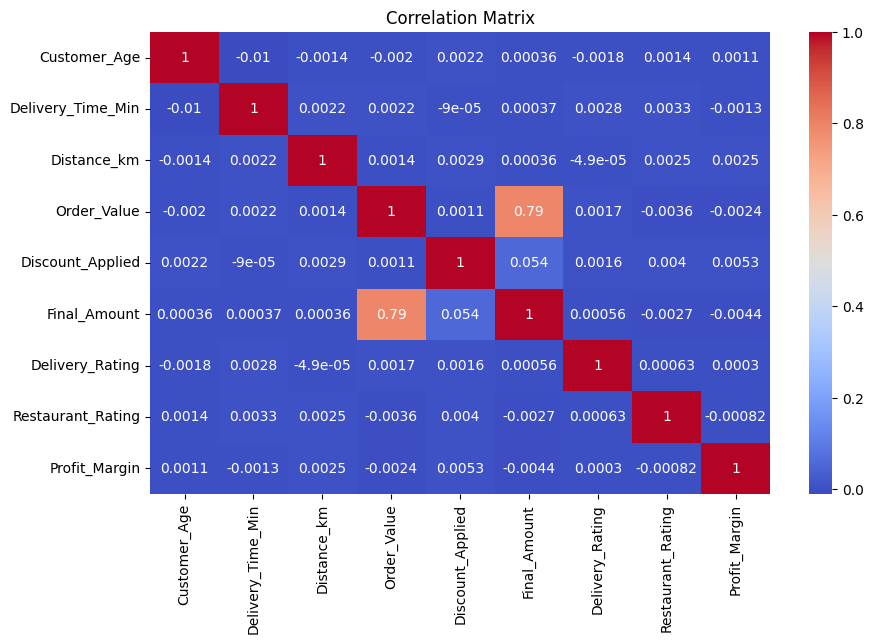

In [18]:
# Correlation
# ----------------------

numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()